<a href="https://colab.research.google.com/github/Hyon2-park/test/blob/main/%ED%91%9C%EC%A4%80%ED%99%94_%EB%B0%8F_%EA%B5%B0%EC%A7%91%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd

df=pd.read_csv('구매내역정보.csv',encoding='cp949')

df

,ID,거래식별ID,점포ID,거래일자,거래시간대,상품대분류명,상품중분류명,구매수량,구매금액
0,B000001,Z000403,B,20140704,21,청과,감귤수박국산기타,1,12900
1,B000001,Z000677,B,20140707,14,낙농,우유,2,1700
2,B000001,Z000677,B,20140707,14,면과자,빵,1,1800
3,B000001,Z001259,B,20140714,17,음주류,주류,1,11200
4,B000001,Z001364,B,20140715,18,낙농,발효유,1,2200
...,...,...,...,...,...,...,...,...,...
55828,B001500,Z016472,A,20140830,16,야채,두채류,1,2290
55829,B001500,Z019236,A,20140920,20,음주류,주류,1,1300
55830,B001500,Z019741,A,20140923,13,낙농,발효유,1,1700
55831,B001500,Z020273,A,20140926,20,야채,계란류,1,4990


# 고객 충성도 지표
## RFM(Recency, Frequency, Monatary)
## 클러스터링 k-means


*   구매 횟수
*   총구매금액


*   평균 객단가
*   고객별로 몇 개의 점포를 이용하는 지


*   상품 다양성
*   점포 다양성

## 파레토 법칙 ( 상위 20% 고객이 80% 매출을 책임 )





## Aggregation 집계 데이터 프레임 만들기
df.groupby ( 'ID' ).agg('집계항목')

In [28]:
customer=df.groupby('ID').agg(총구매금액=("구매금액","sum"),
                            구매횟수 =("거래식별ID","nunique"),
                            평균객단가=("구매금액",'mean'),
                            상품다양성=("상품대분류명","nunique"),
                     점포다양성=("점포ID","nunique"))
customer

,총구매금액,구매횟수,평균객단가,상품다양성,점포다양성
ID,,,,,
B000001,225310,19,5239.767442,11,1
B000002,54900,3,6100.000000,5,1
B000003,109448,17,4560.333333,5,1
B000004,57050,4,4754.166667,6,1
B000005,155984,24,2999.692308,12,1
...,...,...,...,...,...
B001496,232350,13,5667.073171,9,1
B001497,245532,49,2888.611765,12,1
B001498,5720,2,1906.666667,2,1


# 데이터 EDA


In [22]:
display(customer.shape)
display(customer.isnull().sum())
display(customer.dtypes)
display(customer.info())
display(customer.describe())

(1462, 5)

,0
총구매금액,0
구매횟수,0
평균객단가,0
상품다양성,0
점포다양성,0


,0
총구매금액,int64
구매횟수,int64
평균객단가,float64
상품다양성,int64
점포다양성,object


<class 'pandas.core.frame.DataFrame'>
Index: 1462 entries, B000001 to B001500
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   총구매금액   1462 non-null   int64  
 1   구매횟수    1462 non-null   int64  
 2   평균객단가   1462 non-null   float64
 3   상품다양성   1462 non-null   int64  
 4   점포다양성   1462 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 68.5+ KB


None

,총구매금액,구매횟수,평균객단가,상품다양성
count,1.462000e+03,1462.000000,1462.000000,1462.000000
mean,1.773865e+05,13.062927,4505.253211,8.010260
std,1.993380e+05,12.495207,2260.822511,3.760529
min,3.500000e+02,1.000000,350.000000,1.000000
25%,3.728250e+04,4.000000,3332.889535,5.000000
50%,1.126010e+05,10.000000,4277.818376,9.000000
75%,2.426000e+05,19.000000,5244.033784,11.000000
max,1.424099e+06,86.000000,46800.000000,14.000000


# 표준화

Z-score 라이브러리 가져오기


In [29]:
from sklearn.preprocessing import StandardScaler

# 1. 표준화 객체 생성 (z=sclaer)
scaler = StandardScaler()

# 2. 데이터프레임을 표준화 해준다.
X_scale=scaler.fit_transform(customer)


In [30]:
X_scale

array([[ 0.24049539,  0.47531058,  0.32499922,  0.79530382,  0.        ],
       [-0.61467681, -0.80561858,  0.70562482, -0.80076232,  0.        ],
       [-0.3409374 ,  0.31519444,  0.02437121, -0.80076232,  0.        ],
       ...,
       [-0.86147788, -0.88567665, -1.14979203, -1.5987954 ,  0.        ],
       [-0.73677258, -0.32527015, -0.95295039, -0.5347513 ,  0.        ],
       [-0.64875122, -0.24521207, -0.47292096, -1.06677335,  0.        ]])

# 군집 생성


In [ ]:
inertia=[]
for k in range(2,9):
  km=KMeans(n_clusters=k, random_state=42)
  km.fit(X_scale)
  inertia.append(km.inertia_)
  print(k,km.inertia_)
plt.plot(range(2,9),inertia,marker='o')
plt.xlabel("k")
plt.ylabel("inertia")


In [34]:
# 군집분석
from sklearn.cluster import KMeans
km=KMeans(n_clusters=4, random_state=42)
#군집을 4개로 해서 객체 생성
km.fit(X_scale)

KMeans(n_clusters=4, random_state=42)

In [35]:
#각 고객이 어떤 군집에 속하는지 군집을 정한다.
# 1. fit(표준화된 고객 데이터를 보고 어디를 중심으로 나누면 좋을지 중심점 찾음)
# 2. predict(고객별로 군집 셋팅)

customer["cluster"] = km.fit_predict(X_scale)
customer

,총구매금액,구매횟수,평균객단가,상품다양성,점포다양성,cluster
ID,,,,,,
B000001,225310,19,5239.767442,11,1,0
B000002,54900,3,6100.000000,5,1,3
B000003,109448,17,4560.333333,5,1,3
B000004,57050,4,4754.166667,6,1,3
B000005,155984,24,2999.692308,12,1,0
...,...,...,...,...,...,...
B001496,232350,13,5667.073171,9,1,0
B001497,245532,49,2888.611765,12,1,2
B001498,5720,2,1906.666667,2,1,3


# 군집별 데이터 특성 확인

In [39]:
customer.groupby("cluster").mean().round(2)

,총구매금액,구매횟수,평균객단가,상품다양성,점포다양성
cluster,,,,,
0,194554.44,15.20,4518.32,10.22,1.0
1,109754.46,4.72,10077.86,5.49,1.0
2,586932.40,36.81,5064.07,12.70,1.0
3,33168.22,3.98,3576.96,4.31,1.0


# 데이터 시각화


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Text(0, 0.5, '구매횟수')

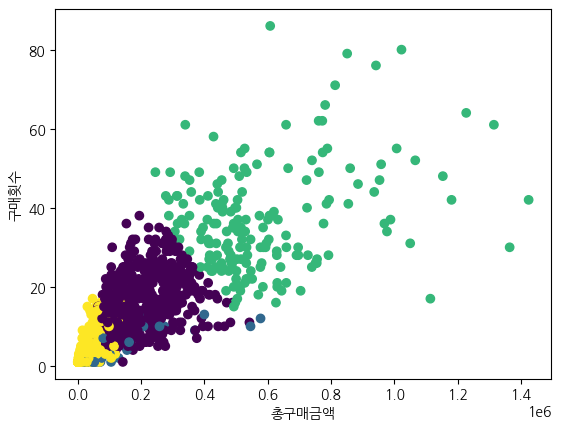

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 구글 코랩에 한글 폰트 설치
!apt-get update -qq
!apt-get install -qq -y fonts-nanum
# 한글 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')


Text(0, 0.5, '구매횟수')

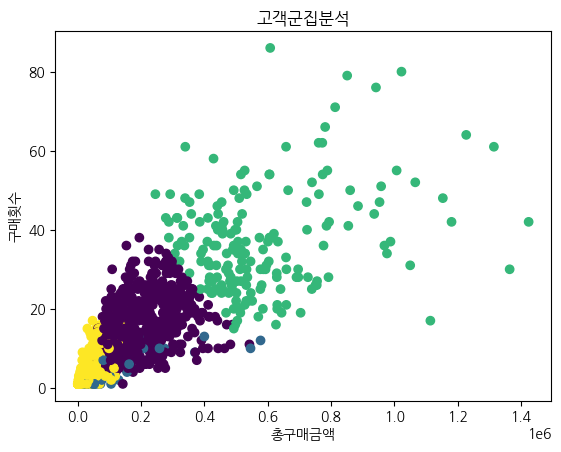

In [47]:
plt.figure()
plt.scatter(
    customer['총구매금액'],
    customer['구매횟수'],
    c=customer['cluster']
)
plt.title("고객군집분석")
plt.xlabel("총구매금액")
plt.ylabel("구매횟수")

In [61]:
cus=customer[["총구매금액","구매횟수","상품다양성"]]
cus

,총구매금액,구매횟수,상품다양성
ID,,,
B000001,225310,19,11
B000002,54900,3,5
B000003,109448,17,5
B000004,57050,4,6
B000005,155984,24,12
...,...,...,...
B001496,232350,13,9
B001497,245532,49,12
B001498,5720,2,2


<Axes: >

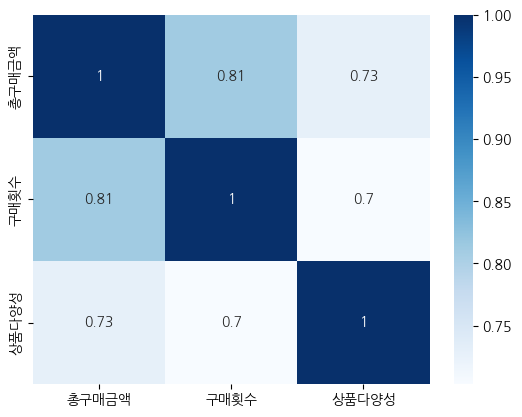

In [64]:
import seaborn as sns
sns.heatmap(cus.corr(),annot=True,cmap="Blues")